Code to set path root

In [6]:
import sys
import os

sys.path.append(os.path.abspath(".."))

# Training model on `fight-weaponized-other-dataset` with 64x64 Image Sizes
* using `datasets`, `transforms` module from `torchvison`
* using `dataloader` module from `torch.utils.data`

## Importing necessary Modules

In [8]:
# Import torch libraries
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn as nn

# Import modules
from modules.architectures.Architecture import Architecture, ResidualBlock
from modules.helper.Trainer import Trainer
from modules.helper.Plotter import plot_training_metrics, plot_testing_history
from modules.helper.Tester import  Tester

Check if CUDA is used

In [3]:
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("CUDA device name:", torch.cuda.get_device_name(0))
    print("Current device index:", torch.cuda.current_device())
    print("Device count:", torch.cuda.device_count())
else:
    print("Running on CPU")

CUDA available: True
CUDA device name: NVIDIA GeForce RTX 4070 Laptop GPU
Current device index: 0
Device count: 1


### Use datasets, dataloader and transforms for loading training Dataset

In [4]:
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.3
    ),
    transforms.RandomHorizontalFlip(p=0.35),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.2)
])
train_dataset = datasets.ImageFolder(
    root = "../datasets/fight-weaponized-other-dataset/train",
    transform = train_transform
)

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=64,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    shuffle=True
)

print("Total Batches => ", len(train_dataloader))

Total Batches =>  34


### Use datasets, dataloader and transforms for loading validation Dataset

In [5]:
val_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

val_dataset = datasets.ImageFolder(
    root = "../datasets/fight-weaponized-other-dataset/val",
    transform = val_transform
)

val_dataloader = DataLoader(
    dataset=val_dataset,
    batch_size=64,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

print("Total Batches => ", len(val_dataloader))

Total Batches =>  8


### Using Model Architecture:
* 3 Convolutional Layers
    - Conv2D
    - BatchNorm2D
    - ReLu
    - MaxPool2D
* 1 Linear Layer
* SDG Optimizer

In [9]:
model = Architecture().to("cuda")

In [10]:
model.add(
    # First Layer
    nn.Conv2d(3, 12, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.BatchNorm2d(12),
    nn.MaxPool2d(2, 2),

    # Second Layer
    nn.Conv2d(12, 24, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.BatchNorm2d(24),
    nn.MaxPool2d(2, 2),

    # Third Layer
    nn.Conv2d(24, 48, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.BatchNorm2d(48),
    nn.MaxPool2d(2, 2),

    # Flatten
    nn.Flatten(),

    # Fully connected layer (for 64x64 input)
    nn.Linear(48 * 8 * 8, 128),
    nn.ReLU(),
    nn.Linear(128, 3)
)

Architecture(
  (blocks): ModuleList(
    (0): Sequential(
      (0): Conv2d(3, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): BatchNorm2d(12, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): Conv2d(12, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (5): ReLU()
      (6): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (8): Conv2d(24, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (9): ReLU()
      (10): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (12): Flatten(start_dim=1, end_dim=-1)
      (13): Linear(in_features=3072, out_featu

### Use Trainer to train and check validations

In [8]:
optimizer = torch.optim.SGD(model.parameters(), lr=1e-2)
criterion = nn.CrossEntropyLoss()

In [9]:
trainer = Trainer(
    model, 
    train_dataloader, 
    val_dataloader, 
    optimizer=optimizer, 
    num_classes=3,
    criterion=criterion,
    device="cuda",
    save_dir="../models/experiment1/",
    save_checkpoints=1,
    print_every=10
    )

In [10]:
history = trainer.fit(100)

Epoch [10/100] | Train Loss: 0.4483 | Val Loss: 0.6863 | Train Acc: 0.8199 | Val Acc: 0.7765 | Train F1: 0.8203 | Val F1: 0.7783
Epoch [20/100] | Train Loss: 0.2958 | Val Loss: 1.5482 | Train Acc: 0.8937 | Val Acc: 0.5465 | Train F1: 0.8940 | Val F1: 0.5345
Epoch [30/100] | Train Loss: 0.1508 | Val Loss: 0.5721 | Train Acc: 0.9518 | Val Acc: 0.8473 | Train F1: 0.9521 | Val F1: 0.8490
Epoch [40/100] | Train Loss: 0.1044 | Val Loss: 2.0632 | Train Acc: 0.9698 | Val Acc: 0.5044 | Train F1: 0.9698 | Val F1: 0.4412
Epoch [50/100] | Train Loss: 0.1734 | Val Loss: 0.7830 | Train Acc: 0.9471 | Val Acc: 0.8031 | Train F1: 0.9475 | Val F1: 0.8044
Epoch [60/100] | Train Loss: 0.0909 | Val Loss: 0.8346 | Train Acc: 0.9674 | Val Acc: 0.8363 | Train F1: 0.9676 | Val F1: 0.8370
Epoch [70/100] | Train Loss: 0.3047 | Val Loss: 1.0863 | Train Acc: 0.9008 | Val Acc: 0.6527 | Train F1: 0.9014 | Val F1: 0.6488
Epoch [80/100] | Train Loss: 0.0353 | Val Loss: 0.7769 | Train Acc: 0.9920 | Val Acc: 0.8186 | Tr

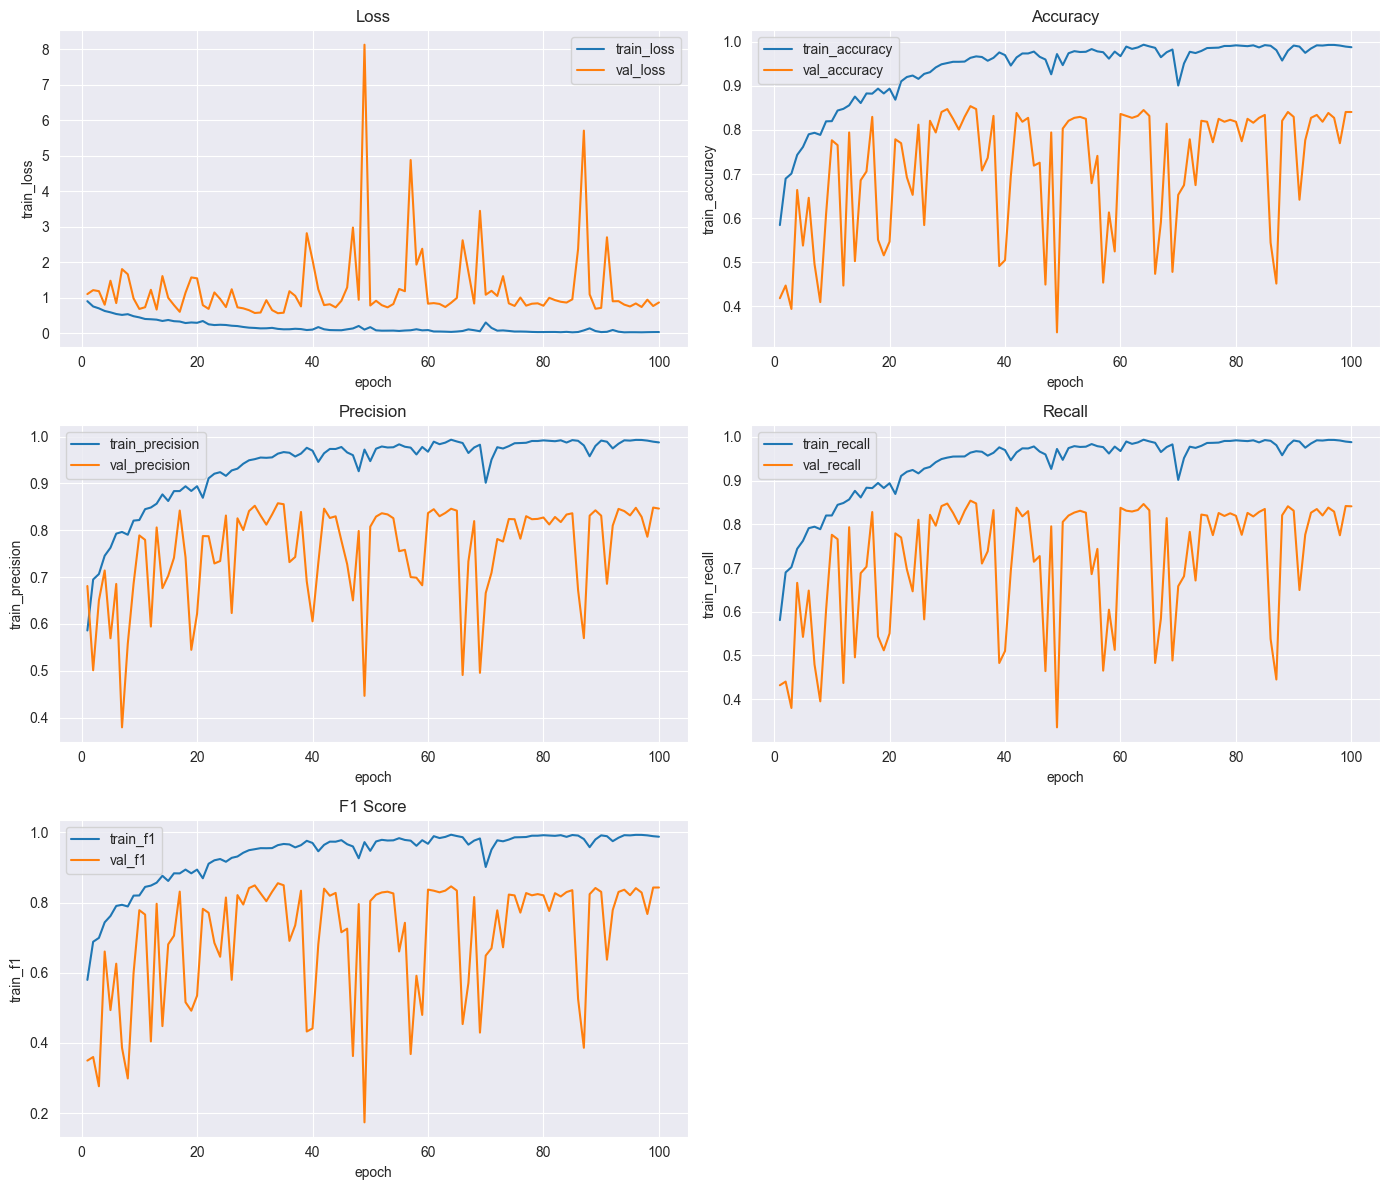

In [11]:
df = plot_training_metrics(history)

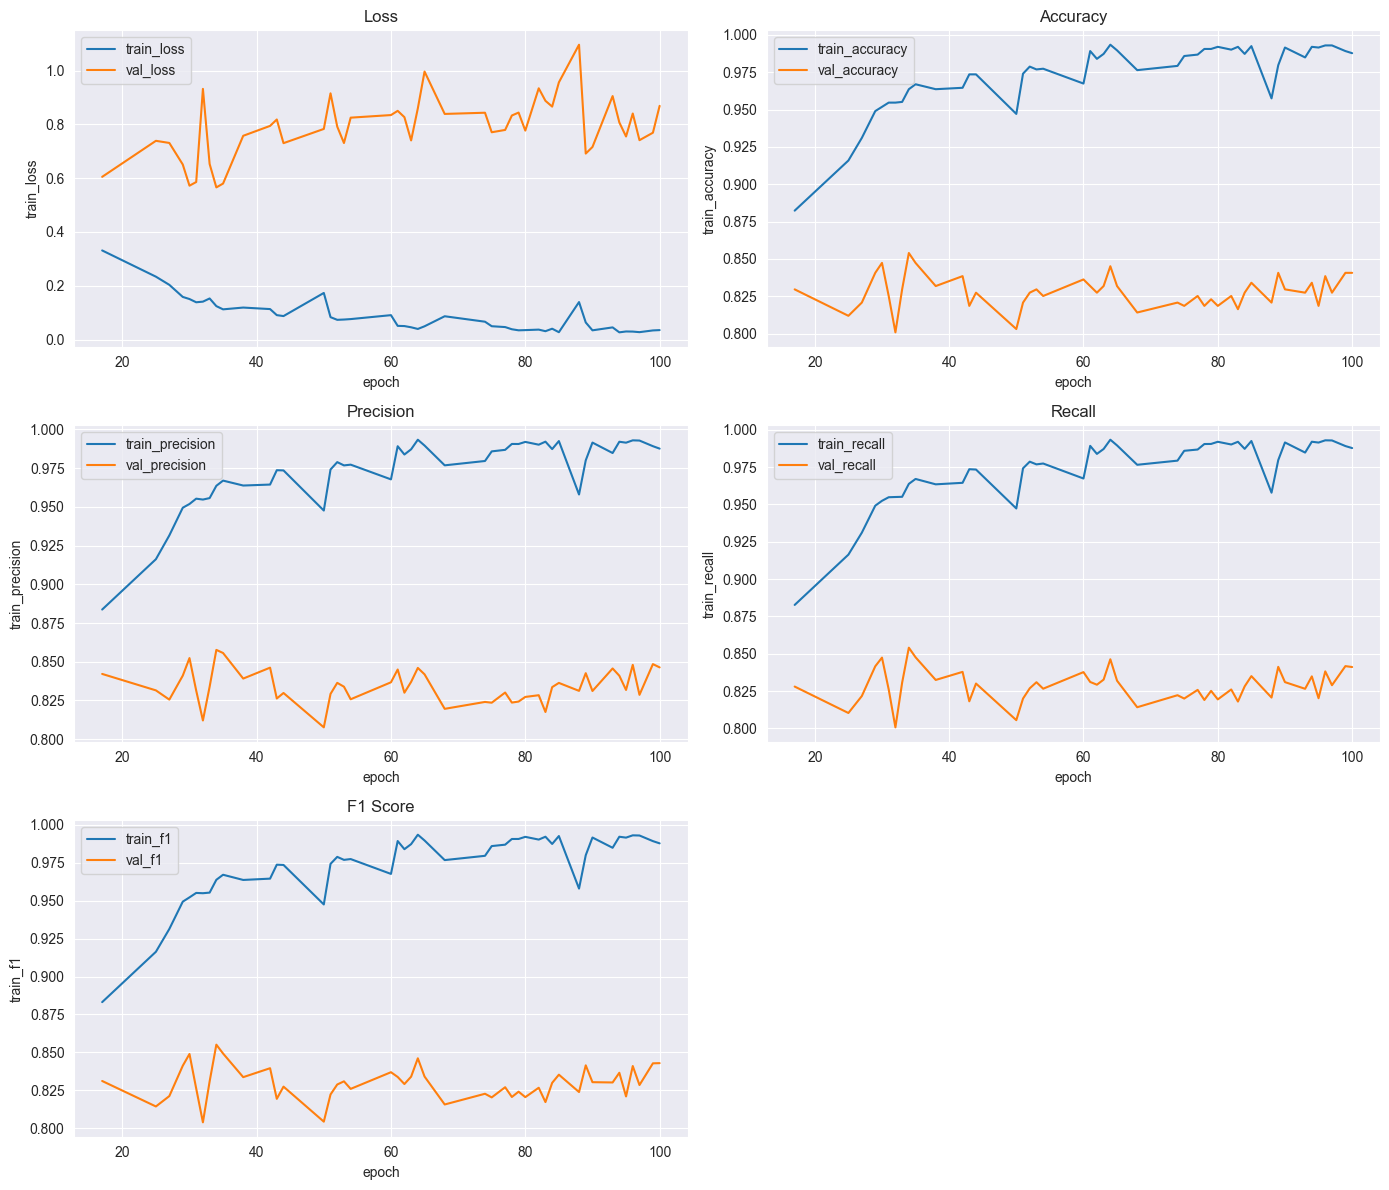

In [14]:
filtered_df = df[
    (df["val_accuracy"] >= 0.8) &
    (df["val_f1"] >= 0.8)
].to_dict()

high_accuracy_df = plot_training_metrics(filtered_df)

### Best Performing Model at Epoch 58
- epoch: 33
- train_loss: 0.1244
- val_loss: 0.56577
- train_accuracy: 0.963
- train_precision: 0.963
- train_recall: 0.963
- train_f1: 0.963
- val_accuracy: 0.853
- val_precision: 0.857
- val_recall: 0.854
- val_f1: 0.855

## Use Tester Module to Test Model

Load Model with State Dict

In [13]:
import copy

test_scores = []

# Transforms of Data
test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

# Dataset Loading From Image dir
test_dataset = datasets.ImageFolder(
    root="../datasets/fight-weaponized-other-dataset/test", 
    transform = test_transform 
    )

# DataLoader
test_loader = DataLoader(
    dataset=test_dataset, 
    batch_size=64,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
    )

# Loops for testing
for i in range(100):
    test_model = copy.deepcopy(model)

    checkpoint = torch.load(
        f"../models/experiment1/model_epoch_{i+1}.pt",
        map_location="cuda"
    )

    test_model.load_state_dict(checkpoint["model"])

    tester = Tester(
        test_model,
        test_loader,
        3,
        torch.nn.CrossEntropyLoss(),
        "cuda"
    )

    result = tester.test(return_predictions=True)

    test_scores.append(result)


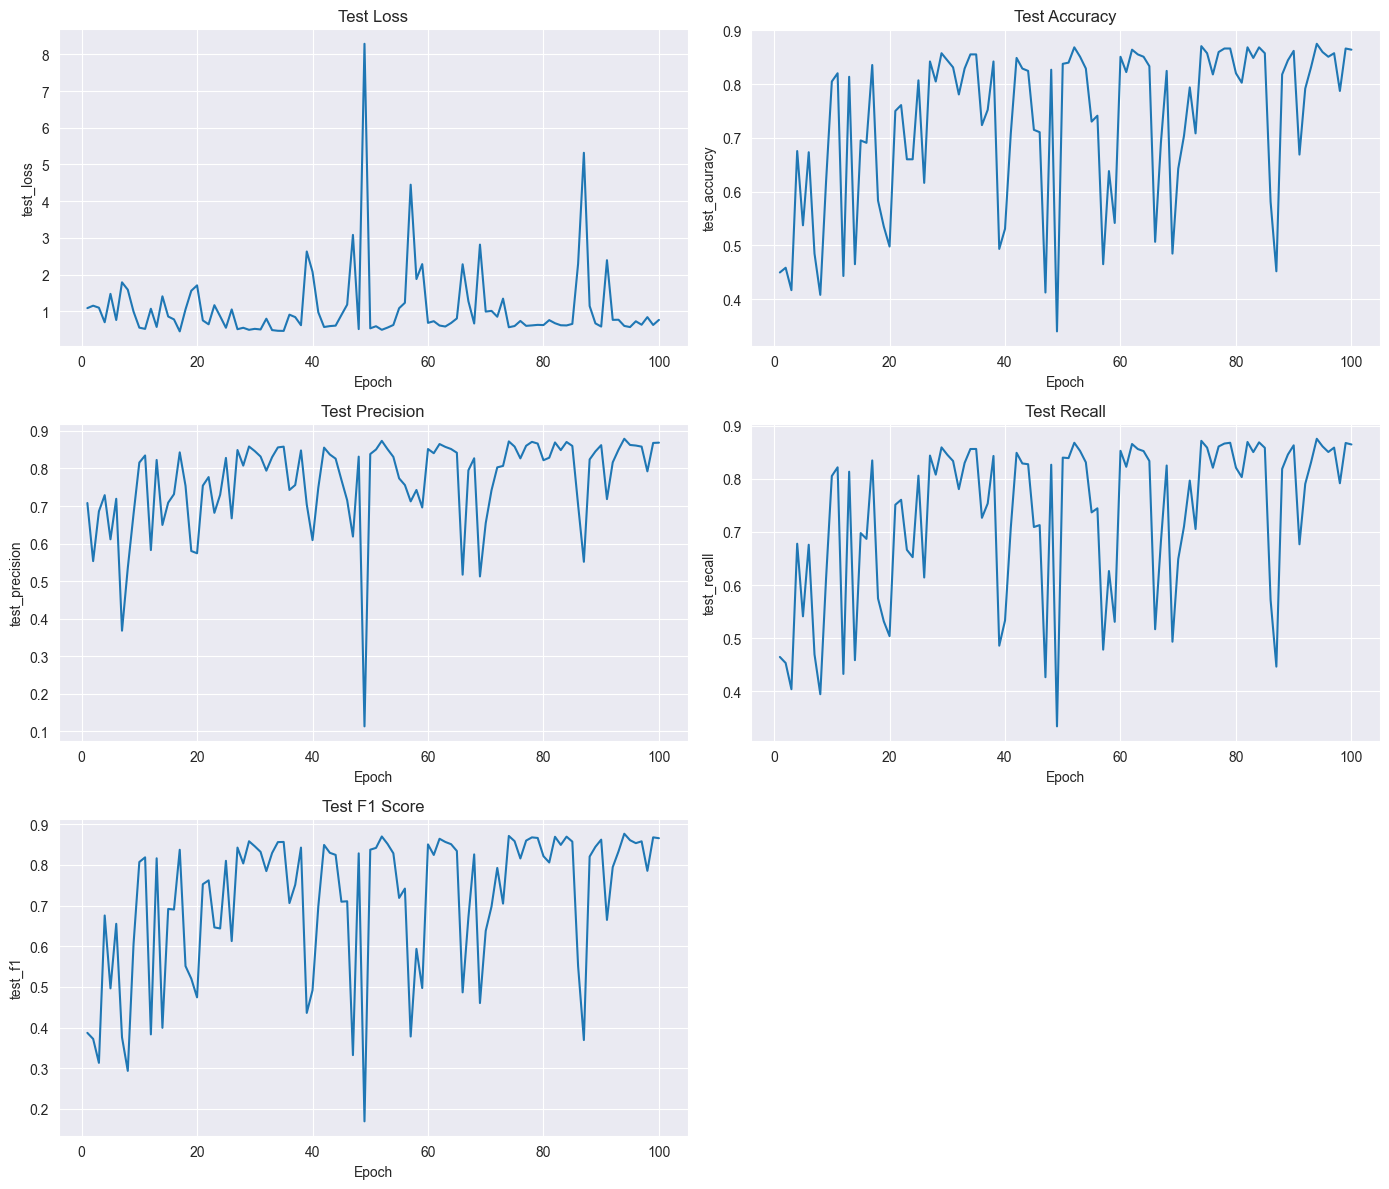

In [14]:
# Plot all 100 epochs
test_metrics_df = plot_testing_history(test_scores)